# NOTEBOOK 1 : CHAIN LADDER AGREGE
## Modelisation de la structure par terme des remboursements anticipes

## Introduction

### Pourquoi une approche agregee ?

La methode Chain Ladder classique s'applique a des donnees longitudinales (suivi du meme contrat dans le temps). Notre base etant une **coupe transversale** (un contrat observe une seule fois), nous devons travailler au **niveau cohorte agrege**.

### Principe

Pour chaque cohorte (groupe de contrats avec la meme periode d'origination) :

1. Calculer le **CRD initial** = capital restant du comptable au moment de l'octroi
2. Calculer le **RA cumule** a chaque age = somme des remboursements anticipes
3. Calculer l'**ER cumule** = RA cumule / CRD initial

On obtient un **triangle cumule** ou :
- Lignes = cohortes
- Colonnes = ages du pret
- Valeurs = ER cumule

### Capital Restant Du (CRD) - Approche comptable

Le CRD comptable est calcule comme :

$$CRD = MTECH \times B\_RESMAT - RA$$

ou :
- $MTECH$ = mensualite
- $B\_RESMAT$ = nombre d'echeances restantes
- $RA$ = remboursement anticipe deja effectue

**Note importante** : Cette formule est la **vision comptable** du capital restant du. Elle differe de l'approche financiere IFRS 9 qui utiliserait l'actualisation des flux. Nous suivons ici les pratiques internes bancaires standard.

### CRD initial (au moment de l'octroi)

Pour reconstituer le CRD initial d'une cohorte :

$$CRD\_initial = MTECH \times NB\_ECH$$

C'est le capital total a rembourser au moment de l'octroi (somme de toutes les mensualites).

### Formule de l'ER cumule

$$ER\_cumule(cohorte, t) = \frac{\sum_{i \in cohorte} RA_i(t)}{CRD\_initial(cohorte)}$$

### Facteurs de developpement Chain Ladder

$$f_j = \frac{\sum_{cohortes} ER\_cumule(c, j+1)}{\sum_{cohortes} ER\_cumule(c, j)}$$

### Gestion des CRD negatifs

La formule $CRD = MTECH \times B\_RESMAT - RA$ peut donner des valeurs negatives si $RA > MTECH \times B\_RESMAT$.

Nous appliquons un **clip a 0** pour les CRD negatifs, ce qui signifie que le contrat est considere comme entierement rembourse.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Chargement et preparation

In [2]:
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

print("Preparation terminee")

Dataset : 100000 lignes, 20 colonnes
Preparation terminee


## Etape 2 : Calcul du CRD (Capital Restant Du) - Approche comptable

### Formule du CRD comptable

$$CRD = MTECH \times B\_RESMAT - RA$$

Cette formule represente le capital restant du selon la **vision comptable** :
- $MTECH \times B\_RESMAT$ = somme des mensualites futures
- On soustrait le RA deja effectue

### CRD initial (reconstitution)

Pour calculer le CRD au moment de l'octroi du pret :

$$CRD\_initial = MTECH \times NB\_ECH$$

C'est la somme totale des mensualites prevues initialement.

### Diagnostic des CRD negatifs

Un CRD negatif signifie que $RA > MTECH \times B\_RESMAT$, ce qui est possible si :
- Le client a rembourse plus que les mensualites restantes
- Cela correspond a un remboursement total ou quasi-total

Nous appliquons un clip a 0 pour ces cas.

In [3]:
# CRD comptable
df["CRD_brut"] = df["MTECH"] * df["B_RESMAT"] - df["RA"]

# Diagnostic CRD negatifs
n_negatifs = (df["CRD_brut"] < 0).sum()
pct_negatifs = (df["CRD_brut"] < 0).mean()

print("DIAGNOSTIC CRD COMPTABLE")
print("=" * 60)
print(f"CRD negatifs : {n_negatifs} ({pct_negatifs:.2%})")
print(f"CRD min : {df['CRD_brut'].min():.2f} EUR")
print(f"CRD max : {df['CRD_brut'].max():.2f} EUR")
print(f"CRD moyen : {df['CRD_brut'].mean():.2f} EUR")

# Appliquer clip a 0
df["CRD"] = df["CRD_brut"].clip(lower=0)

# Filtrer les contrats avec CRD = 0 (deja entierement rembourses)
df = df[df["CRD"] > 0]

print(f"\nApres filtrage CRD > 0 : {len(df)} contrats")

# CRD initial (reconstitution pour chaque contrat)
df["CRD_initial"] = df["MTECH"] * df["NB_ECH"]

print(f"\nCRD initial moyen : {df['CRD_initial'].mean():.2f} EUR")
print(f"CRD actuel moyen  : {df['CRD'].mean():.2f} EUR")

# Calcul ER individuel
df["ER_obs"] = (df["RA"] / df["CRD"]).clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

print(f"\nER_obs moyen : {df['ER_obs'].mean():.4f}")
print(f"FLAG_ER (taux RA) : {df['FLAG_ER'].mean():.2%}")

DIAGNOSTIC CRD COMPTABLE
CRD negatifs : 17348 (65.42%)
CRD min : -249969.99 EUR
CRD max : 318736.15 EUR
CRD moyen : -894.80 EUR

Apres filtrage CRD > 0 : 8901 contrats

CRD initial moyen : 20731.05 EUR
CRD actuel moyen  : 11693.32 EUR

ER_obs moyen : 0.4041
FLAG_ER (taux RA) : 91.36%


## Etape 3 : Creation des cohortes

In [4]:
# Cohorte = periode d'origination
df["Date_origination"] = df["DARRET"] - pd.to_timedelta(df["AGE_PRET"] * 30, unit='D')
df["Cohorte"] = df["Date_origination"].dt.to_period('M')

print(f"Nombre de cohortes : {df['Cohorte'].nunique()}")
print(f"Periode : {df['Cohorte'].min()} a {df['Cohorte'].max()}")

# Distribution des cohortes
cohorte_counts = df['Cohorte'].value_counts().sort_index()
print(f"\nCohortes avec plus de 100 contrats : {(cohorte_counts >= 100).sum()}")
print(f"Taille mediane cohorte : {cohorte_counts.median():.0f} contrats")

Nombre de cohortes : 216
Periode : 1994-09 a 2023-10

Cohortes avec plus de 100 contrats : 33
Taille mediane cohorte : 18 contrats


## Etape 3 : Construction du triangle agrege

### Methode

Pour chaque cellule (cohorte, age) :

$$ER\_cumule(c, t) = \frac{\sum_{i \in c} RA_i}{\sum_{i \in c} CRD\_initial_i}$$

Le denominateur **CRD_initial agrege** est constant pour chaque cohorte (independant de l'age), ce qui garantit que l'ER cumule est croissant avec l'age.

In [15]:
# ============================================================================
# FILTRAGE COHORTES RECENTES (5 dernières années)
# ============================================================================

print("AVANT FILTRAGE :")
print(f"  Nombre de contrats : {len(df)}")
print(f"  Nombre de cohortes : {df['Cohorte'].nunique()}")
print(f"  Periode : {df['Cohorte'].min()} a {df['Cohorte'].max()}")

# Filtrer sur les 5 dernières années (60 mois)
date_cutoff = df['Cohorte'].max() - 60
df_recent = df[df['Cohorte'] >= date_cutoff].copy()

print(f"\nAPRES FILTRAGE (cohortes >= {date_cutoff}) :")
print(f"  Nombre de contrats : {len(df_recent)}")
print(f"  Nombre de cohortes : {df_recent['Cohorte'].nunique()}")
print(f"  Periode : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")

# Distribution des cohortes récentes
print(f"\nDistribution des cohortes recentes :")
cohorte_counts = df_recent['Cohorte'].value_counts().sort_index()
print(f"  Cohortes avec >= 10 contrats : {(cohorte_counts >= 10).sum()}")
print(f"  Taille mediane cohorte : {cohorte_counts.median():.0f} contrats")

# REMPLACER df par df_recent pour la suite
df = df_recent.copy()

print(f"\n✓ Dataset filtre pret pour construction du triangle")

AVANT FILTRAGE :
  Nombre de contrats : 5292
  Nombre de cohortes : 61
  Periode : 2018-10 a 2023-10

APRES FILTRAGE (cohortes >= 2018-10) :
  Nombre de contrats : 5292
  Nombre de cohortes : 61
  Periode : 2018-10 a 2023-10

Distribution des cohortes recentes :
  Cohortes avec >= 10 contrats : 59
  Taille mediane cohorte : 83 contrats

✓ Dataset filtre pret pour construction du triangle


In [17]:
# CRD initial par cohorte = somme des CRD initiaux
crd_initial_cohorte = df.groupby('Cohorte')['CRD_initial'].sum()
print(f"CRD initial total : {crd_initial_cohorte.sum():,.0f} EUR")
print(f"CRD initial moyen par cohorte : {crd_initial_cohorte.mean():,.0f} EUR")

# RA agrege par cohorte et age
ra_agrege = df.groupby(['Cohorte', 'AGE_PRET'])['RA'].sum().reset_index()

# Joindre CRD initial
ra_agrege = ra_agrege.merge(
    crd_initial_cohorte.reset_index().rename(columns={'CRD_initial': 'CRD_initial_cohorte'}),
    on='Cohorte'
)

# ER cumule
ra_agrege['ER_cumule'] = ra_agrege['RA'] / ra_agrege['CRD_initial_cohorte']



# Triangle cumule
triangle_cumule = ra_agrege.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_cumule',
    aggfunc='sum'
)

# Volume (nombre de contrats par cellule)
triangle_volume = df.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# Filtrer cellules avec moins de 3 contrats
triangle_filtre = triangle_cumule.copy()
triangle_filtre[triangle_volume < 3] = np.nan

print(f"\nDimensions triangle : {triangle_filtre.shape}")
print(f"Taux remplissage : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")
print(f"\nExtrait triangle (5 cohortes x 10 ages) :")
print(triangle_filtre.iloc[:5, :10].round(4))

CRD initial total : 87,696,708 EUR
CRD initial moyen par cohorte : 1,437,651 EUR

Dimensions triangle : (61, 62)
Taux remplissage : 22.5%

Extrait triangle (5 cohortes x 10 ages) :
AGE_PRET  0.0     1.0    2.0     3.0     4.0     5.0     6.0     7.0     8.0  \
Cohorte                                                                        
2018-10   NaN     NaN    NaN  0.0073  0.0078  0.0086  0.0042  0.0025  0.0011   
2018-11   NaN     NaN -0.001     NaN -0.0072  0.0086  0.0079  0.0048     NaN   
2018-12   NaN     NaN  0.004  0.0110  0.0012 -0.0011     NaN  0.0078  0.0135   
2019-01   NaN  0.0059    NaN -0.0014     NaN     NaN  0.0080  0.0026  0.0019   
2019-02   NaN     NaN    NaN     NaN  0.0014  0.0073  0.0076  0.0077  0.0063   

AGE_PRET     9.0  
Cohorte           
2018-10   0.0019  
2018-11   0.0025  
2018-12   0.0015  
2019-01   0.0036  
2019-02   0.0149  


In [13]:
print("=" * 80)
print("DIAGNOSTIC DES DONNEES")
print("=" * 80)

print("\n1. DARRET (date d'arrete) :")
print(df['DARRET'].describe())
print(f"   Min : {df['DARRET'].min()}")
print(f"   Max : {df['DARRET'].max()}")

print("\n2. AGE_PRET (age du pret en mois) :")
print(df['AGE_PRET'].describe())
print(f"   Min : {df['AGE_PRET'].min()}")
print(f"   Max : {df['AGE_PRET'].max()}")

print("\n3. COHORTES calculees :")
print(df['Cohorte'].value_counts().sort_index().head(10))
print("...")
print(df['Cohorte'].value_counts().sort_index().tail(10))

print("\n4. Nombre de contrats par tranche AGE_PRET :")
print(pd.cut(df['AGE_PRET'], bins=[0, 12, 24, 36, 60, 120, 999]).value_counts().sort_index())

print("\n5. Triangle : cellules non-vides par age :")
for age in [0, 1, 2, 3, 6, 12, 24, 36, 60]:
    if age in triangle_filtre.columns:
        nb_non_nan = (~triangle_filtre[age].isna()).sum()
        print(f"   Age {age:3d} mois : {nb_non_nan:4d} cohortes avec donnees")

DIAGNOSTIC DES DONNEES

1. DARRET (date d'arrete) :
count                             8901
mean     2021-04-04 23:11:57.087967744
min                2019-01-01 00:00:00
25%                2020-01-01 00:00:00
50%                2021-03-01 00:00:00
75%                2022-06-01 00:00:00
max                2023-12-01 00:00:00
Name: DARRET, dtype: object
   Min : 2019-01-01 00:00:00
   Max : 2023-12-01 00:00:00

2. AGE_PRET (age du pret en mois) :
count    8901.000000
mean       28.558140
std        30.842902
min         0.000000
25%         9.000000
50%        20.000000
75%        38.000000
max       299.000000
Name: AGE_PRET, dtype: float64
   Min : 0.0
   Max : 299.0

3. COHORTES calculees :
Cohorte
1994-09    1
1995-01    1
1995-02    1
1995-06    1
1995-08    1
1995-09    1
1995-10    1
1995-11    6
1996-02    1
1996-03    1
Freq: M, Name: count, dtype: int64
...
Cohorte
2023-01    36
2023-02    28
2023-03    26
2023-04    19
2023-05    20
2023-06    20
2023-07    14
2023-08     5
202

### Visualisation du triangle agrege

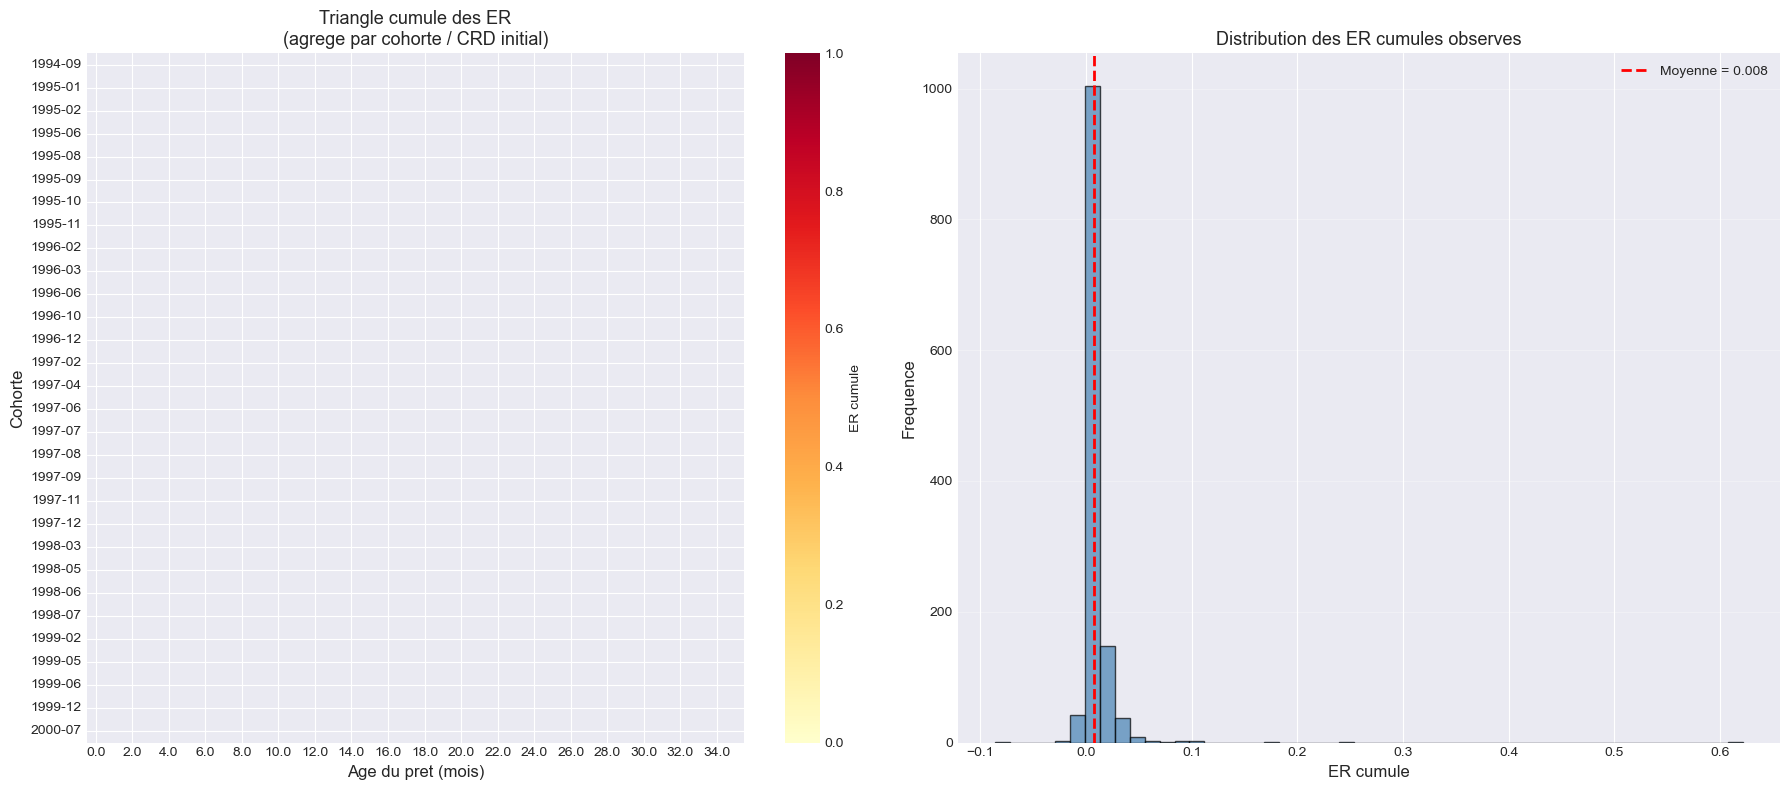

ER cumule moyen observe : 0.0080
ER cumule median : 0.0044
ER cumule max : 0.6213


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Triangle complet
sns.heatmap(triangle_filtre.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Cohorte', fontsize=12)
axes[0].set_title('Triangle cumule des ER\n(agrege par cohorte / CRD initial)', fontsize=13)

# Distribution des ER cumules observes
er_values = triangle_filtre.values.flatten()
er_values = er_values[~np.isnan(er_values)]
axes[1].hist(er_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('ER cumule', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des ER cumules observes', fontsize=13)
axes[1].axvline(np.nanmean(er_values), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne = {np.nanmean(er_values):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"ER cumule moyen observe : {np.nanmean(er_values):.4f}")
print(f"ER cumule median : {np.nanmedian(er_values):.4f}")
print(f"ER cumule max : {np.nanmax(er_values):.4f}")

## Etape 4 : Calcul des facteurs de developpement

### Formule

$$f_j = \frac{\sum_{c : ER(c,j+1) \neq NaN} ER\_cumule(c, j+1)}{\sum_{c : ER(c,j+1) \neq NaN} ER\_cumule(c, j)}$$

Les facteurs sont calcules comme le ratio des **sommes agregees** (pas des moyennes), ce qui est la methode standard Chain Ladder.

### Contrainte de monotonie

L'ER cumule etant croissant avec l'age, les facteurs doivent satisfaire $f_j \geq 1$.

On applique un filtre pour exclure les facteurs < 0.8 (anomalies de donnees).

In [7]:
def calculate_cl_factors_agrege(triangle, min_cohortes=3, min_factor=0.8, max_factor=3.0):
    """
    Calcule les facteurs de developpement Chain Ladder sur donnees agregees.
    
    Methode : ratio des sommes (standard actuariel)
    f_j = sum(ER(c, j+1)) / sum(ER(c, j))
    
    Parameters:
    -----------
    triangle : DataFrame (triangle cumule)
    min_cohortes : nombre minimum de cohortes
    min_factor : facteur minimum accepte
    max_factor : facteur maximum accepte
    
    Returns:
    --------
    dict {age: facteur}
    """
    factors = {}
    
    for j in range(len(triangle.columns) - 1):
        col_j = triangle.columns[j]
        col_j1 = triangle.columns[j + 1]
        
        # Cohortes avec donnees aux deux ages
        mask = triangle[col_j].notna() & triangle[col_j1].notna() & (triangle[col_j] > 0)
        
        if mask.sum() >= min_cohortes:
            sum_j = triangle.loc[mask, col_j].sum()
            sum_j1 = triangle.loc[mask, col_j1].sum()
            
            if sum_j > 0:
                factor = sum_j1 / sum_j
                
                # Filtrer facteurs aberrants
                if min_factor <= factor <= max_factor:
                    factors[col_j] = factor
                else:
                    factors[col_j] = 1.0
            else:
                factors[col_j] = 1.0
        else:
            factors[col_j] = 1.0
    
    return factors

# Calculer facteurs
factors_cl = calculate_cl_factors_agrege(triangle_filtre, min_cohortes=3)

print("FACTEURS DE DEVELOPPEMENT CHAIN LADDER AGREGE")
print("=" * 60)
print(f"{'Age':>5} {'Facteur':>10} {'Interpretation'}")
print("-" * 60)

for age, factor in sorted(factors_cl.items())[:30]:
    if factor >= 1.05:
        interp = "Croissance forte"
    elif factor >= 1.01:
        interp = "Croissance moderee"
    elif factor >= 0.99:
        interp = "Stable"
    else:
        interp = "Anomalie"
    print(f"{age:>5.0f} {factor:>10.4f} {interp}")

print(f"\nTotal facteurs calcules : {len(factors_cl)}")

FACTEURS DE DEVELOPPEMENT CHAIN LADDER AGREGE
  Age    Facteur Interpretation
------------------------------------------------------------
    0     1.0000 Stable
    1     2.8498 Croissance forte
    2     1.0000 Stable
    3     1.0751 Croissance forte
    4     0.9211 Anomalie
    5     1.3951 Croissance forte
    6     1.1024 Croissance forte
    7     0.8435 Anomalie
    8     0.8724 Anomalie
    9     0.9266 Anomalie
   10     1.0704 Croissance forte
   11     0.8081 Anomalie
   12     0.8743 Anomalie
   13     1.0000 Stable
   14     1.2046 Croissance forte
   15     1.0000 Stable
   16     1.1669 Croissance forte
   17     1.0000 Stable
   18     1.1052 Croissance forte
   19     0.8766 Anomalie
   20     1.1794 Croissance forte
   21     1.0000 Stable
   22     1.1241 Croissance forte
   23     1.1031 Croissance forte
   24     1.0000 Stable
   25     1.1675 Croissance forte
   26     0.8091 Anomalie
   27     1.0000 Stable
   28     1.0000 Stable
   29     1.0056 Stable

Tota

### Visualisation des facteurs

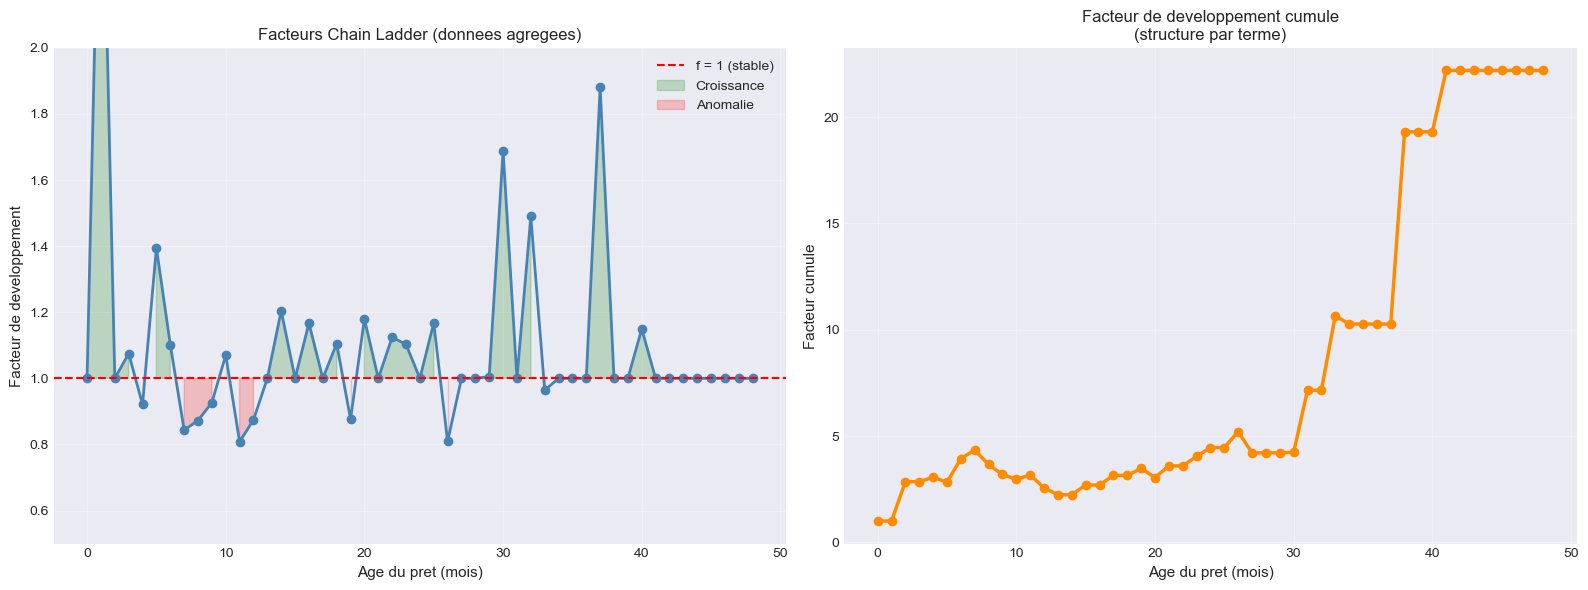

Interpretation :
  - Facteur > 1 : les RA augmentent d'un age a l'autre
  - Facteur cumule = ER attendu si ER initial = 1
  - La courbe du facteur cumule = structure par terme des RA


In [8]:
ages_plot = sorted([k for k in factors_cl.keys() if k <= 48])
vals_plot = [factors_cl[a] for a in ages_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Facteurs bruts
axes[0].plot(ages_plot, vals_plot, 'o-', linewidth=2, markersize=6, color='steelblue')
axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='f = 1 (stable)')
axes[0].fill_between(ages_plot, 1.0, vals_plot, 
                      where=[v >= 1 for v in vals_plot],
                      alpha=0.2, color='green', label='Croissance')
axes[0].fill_between(ages_plot, vals_plot, 1.0,
                      where=[v < 1 for v in vals_plot],
                      alpha=0.2, color='red', label='Anomalie')
axes[0].set_xlabel('Age du pret (mois)', fontsize=11)
axes[0].set_ylabel('Facteur de developpement', fontsize=11)
axes[0].set_title('Facteurs Chain Ladder (donnees agregees)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 2.0)

# Facteur cumule (produit des facteurs = ER attendu final)
factor_cumul = [1.0]
cumul = 1.0
for age in ages_plot[:-1]:
    cumul *= factors_cl.get(age, 1.0)
    factor_cumul.append(cumul)

axes[1].plot(ages_plot, factor_cumul, 'o-', linewidth=2.5, markersize=6, color='darkorange')
axes[1].set_xlabel('Age du pret (mois)', fontsize=11)
axes[1].set_ylabel('Facteur cumule', fontsize=11)
axes[1].set_title('Facteur de developpement cumule\n(structure par terme)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Facteur > 1 : les RA augmentent d'un age a l'autre")
print("  - Facteur cumule = ER attendu si ER initial = 1")
print("  - La courbe du facteur cumule = structure par terme des RA")

## Etape 5 : Projection du triangle

On complete les cohortes incompletes en appliquant les facteurs :

$$ER\_cumule(c, j+1) = ER\_cumule(c, j) \times f_j$$

In [9]:
def project_triangle_agrege(triangle, factors, max_age=60):
    """
    Complete le triangle en projetant les cohortes incompletes.
    """
    tri_proj = triangle.copy()
    
    for cohorte in tri_proj.index:
        last_valid = tri_proj.loc[cohorte].last_valid_index()
        
        if last_valid is None:
            continue
            
        current_val = tri_proj.loc[cohorte, last_valid]
        
        for age in tri_proj.columns:
            if age <= last_valid:
                continue
            if age > max_age:
                break
            
            prev_age = tri_proj.columns[list(tri_proj.columns).index(age) - 1]
            factor = factors.get(prev_age, 1.0)
            current_val = current_val * factor
            tri_proj.loc[cohorte, age] = current_val
    
    return tri_proj

triangle_projete = project_triangle_agrege(triangle_filtre, factors_cl, max_age=60)

print(f"Taux remplissage avant projection : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")
print(f"Taux remplissage apres projection : {(~triangle_projete.isna()).sum().sum() / triangle_projete.size:.1%}")

Taux remplissage avant projection : 3.2%
Taux remplissage apres projection : 9.3%


### Visualisation triangle projete

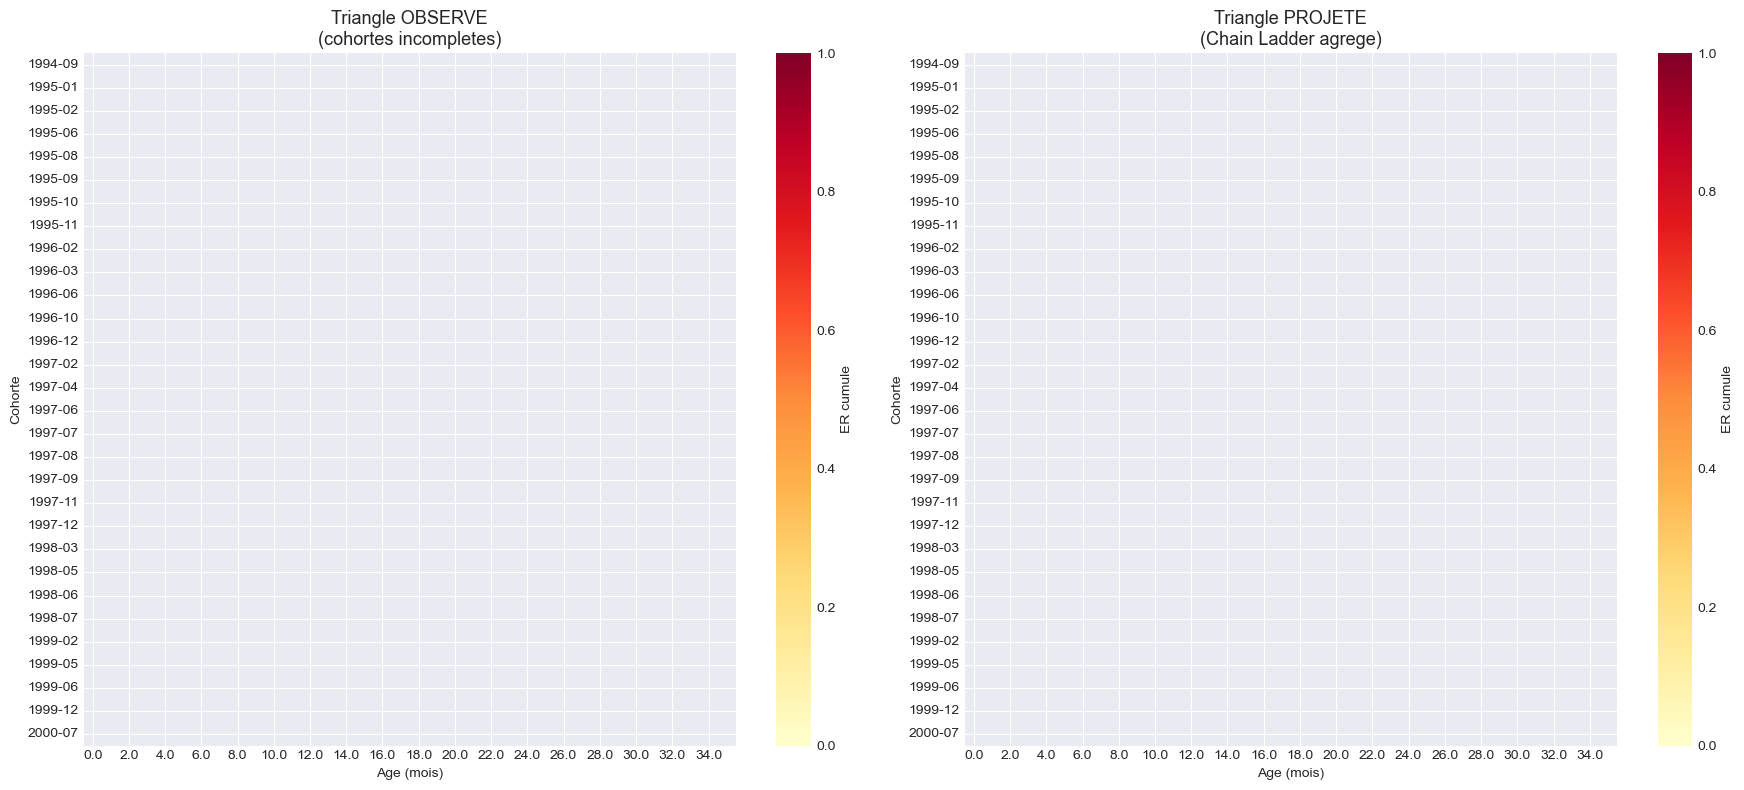

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(triangle_filtre.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Triangle OBSERVE\n(cohortes incompletes)', fontsize=13)
axes[0].set_xlabel('Age (mois)')
axes[0].set_ylabel('Cohorte')

sns.heatmap(triangle_projete.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Triangle PROJETE\n(Chain Ladder agrege)', fontsize=13)
axes[1].set_xlabel('Age (mois)')
axes[1].set_ylabel('Cohorte')

plt.tight_layout()
plt.show()

## Etape 6 : Courbe ER baseline (structure par terme)

La courbe finale est la **moyenne des ER cumules projetes** par age :

$$ER\_baseline(t) = \frac{1}{N} \sum_{c=1}^{N} ER\_projete(c, t)$$

Cette courbe represente la **structure par terme des remboursements anticipes** : combien de l'encours initial est rembourse anticipativement en moyenne a chaque horizon.

STRUCTURE PAR TERME - ER BASELINE
  Age  ER baseline      Q10      Q90
------------------------------------------------------------
    1       0.0349  -0.0007   0.0231
    2       0.0622  -0.0022   0.0198
    3       0.0437  -0.0048   0.0131
    4       0.0498   0.0009   0.0315
    5       0.0553   0.0010   0.0243
    6       0.0679   0.0022   0.0360
    7       0.0651   0.0030   0.0631
    8       0.0564   0.0034   0.0302
    9       0.0521   0.0016   0.0345
   10       0.0554   0.0024   0.0310
   11       0.0543   0.0015   0.0383
   12       0.0453   0.0026   0.0316
   13       0.0380   0.0013   0.0220
   14       0.0346   0.0019   0.0247
   15       0.0491   0.0015   0.0318
   16       0.0452   0.0008   0.0296
   17       0.0526   0.0005   0.0345
   18       0.0589   0.0022   0.0348
   19       0.0566   0.0018   0.0381
   20       0.0557   0.0016   0.0337
   21       0.0600   0.0011   0.0395
   22       0.0579   0.0008   0.0394
   23       0.0566   0.0008   0.0382


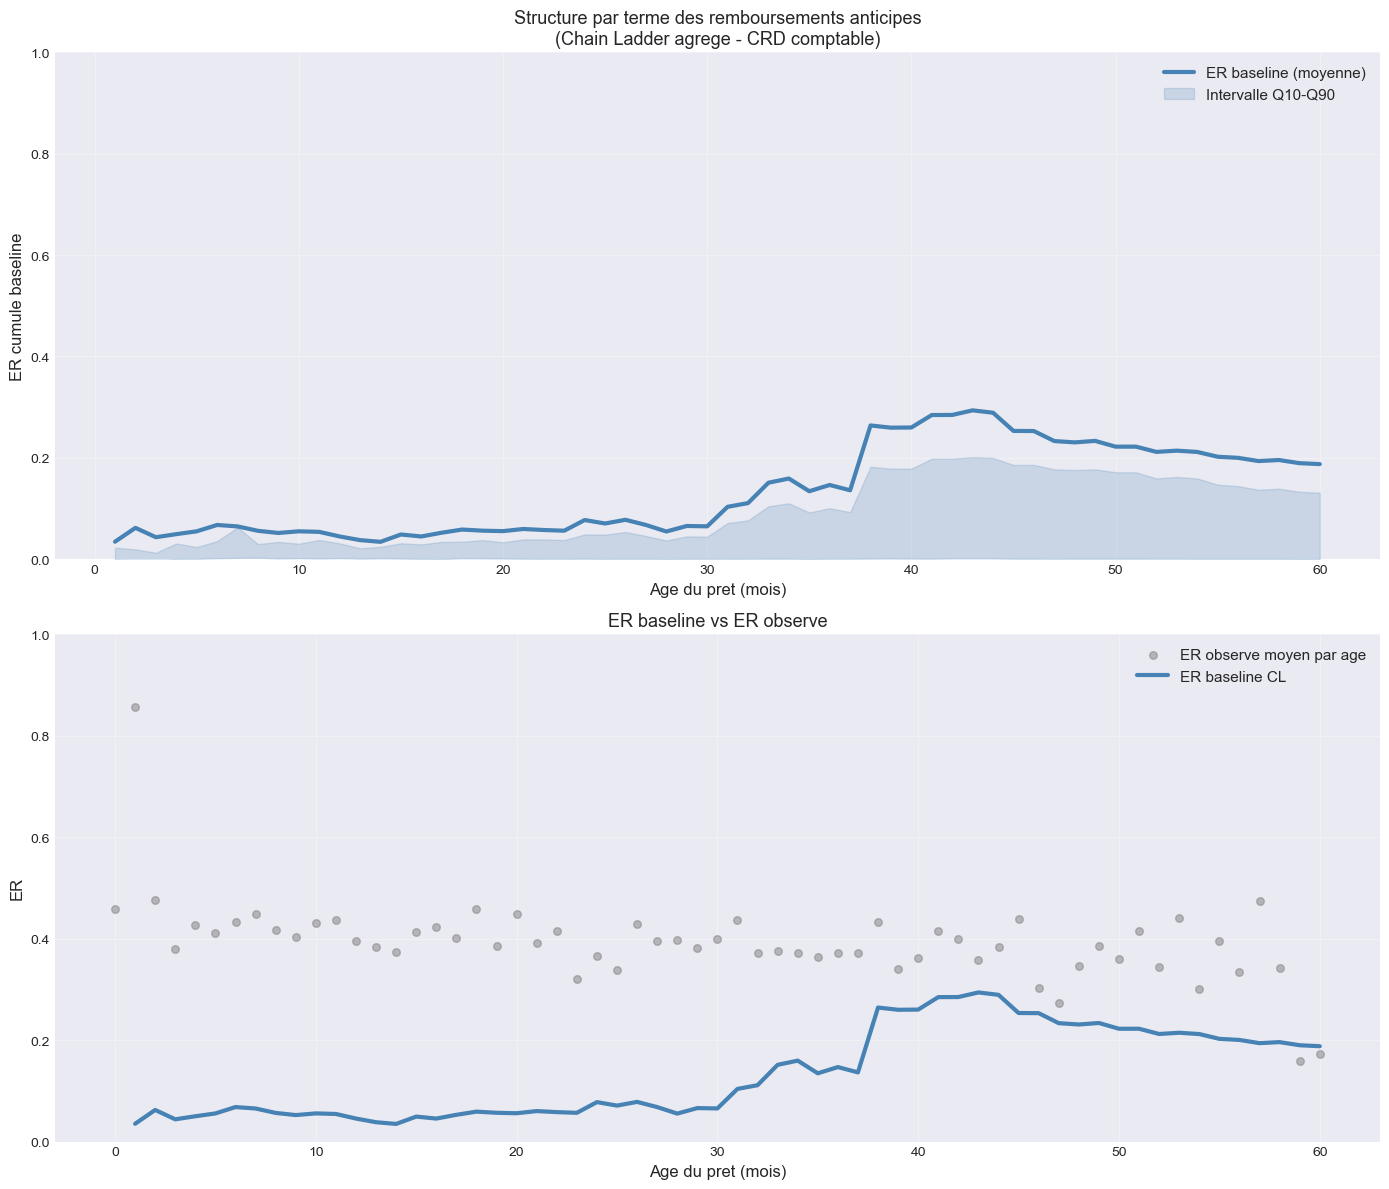

In [11]:
# Structure par terme : moyenne des ER cumules par age
er_baseline = triangle_projete.mean(axis=0, skipna=True)

# Intervalle de confiance (quantiles)
er_q10 = triangle_projete.quantile(0.10, axis=0)
er_q90 = triangle_projete.quantile(0.90, axis=0)

print("STRUCTURE PAR TERME - ER BASELINE")
print("=" * 60)
print(f"{'Age':>5} {'ER baseline':>12} {'Q10':>8} {'Q90':>8}")
print("-" * 60)
for age in sorted(er_baseline.index)[:24]:
    if not np.isnan(er_baseline[age]):
        print(f"{age:>5.0f} {er_baseline[age]:>12.4f} {er_q10[age]:>8.4f} {er_q90[age]:>8.4f}")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ages_baseline = sorted([a for a in er_baseline.index if a <= 60 and not np.isnan(er_baseline[a])])
vals_baseline = [er_baseline[a] for a in ages_baseline]
vals_q10 = [er_q10[a] for a in ages_baseline]
vals_q90 = [er_q90[a] for a in ages_baseline]

# Courbe baseline
axes[0].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', label='ER baseline (moyenne)')
axes[0].fill_between(ages_baseline, vals_q10, vals_q90,
                      alpha=0.2, color='steelblue', label='Intervalle Q10-Q90')
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('ER cumule baseline', fontsize=12)
axes[0].set_title('Structure par terme des remboursements anticipes\n(Chain Ladder agrege - CRD comptable)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Comparaison avec ER observe par age
er_obs_age = df.groupby('AGE_PRET')['ER_obs'].mean()
er_obs_age = er_obs_age[er_obs_age.index <= 60]

axes[1].scatter(er_obs_age.index, er_obs_age.values, alpha=0.5, s=30,
                color='gray', label='ER observe moyen par age')
axes[1].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', label='ER baseline CL')
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('ER', fontsize=12)
axes[1].set_title('ER baseline vs ER observe', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Etape 7 : Evaluation de la performance

In [12]:
# Mapper baseline sur dataframe
df['ER_baseline_CL'] = df['AGE_PRET'].map(er_baseline)
df['ER_baseline_CL'] = df['ER_baseline_CL'].fillna(method='ffill').fillna(method='bfill')
df['ER_baseline_CL'] = df['ER_baseline_CL'].fillna(er_baseline.mean())

# Split
X_dummy = df[['AGE_PRET']]
y = df['ER_obs']
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y, test_size=0.2, random_state=42)

y_pred = df.loc[y_test.index, 'ER_baseline_CL'].values

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("PERFORMANCE - CHAIN LADDER AGREGE")
print("=" * 60)
print(f"R2   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print()
print("Note : Performance attendue similaire a Chain Ladder classique")
print("La valeur ajoutee est la STRUCTURE PAR TERME, pas la prediction individuelle")
print("La combinaison avec Markov (Notebook 2) ameliorera la performance")

# Sauvegarder baseline pour Notebook 2 (Markov)
er_baseline.to_csv('cl_baseline_structure_terme.csv', header=['ER_baseline'])
factors_df = pd.DataFrame({'Age': list(factors_cl.keys()), 'Facteur': list(factors_cl.values())})
factors_df.to_csv('cl_factors.csv', index=False)

print("\nFichiers sauvegardes :")
print("  - cl_baseline_structure_terme.csv (utilise dans NB2)")
print("  - cl_factors.csv")

PERFORMANCE - CHAIN LADDER AGREGE
R2   : -0.6194
RMSE : 0.5158
MAE  : 0.3608

Note : Performance attendue similaire a Chain Ladder classique
La valeur ajoutee est la STRUCTURE PAR TERME, pas la prediction individuelle
La combinaison avec Markov (Notebook 2) ameliorera la performance

Fichiers sauvegardes :
  - cl_baseline_structure_terme.csv (utilise dans NB2)
  - cl_factors.csv


## Synthese

### Formule du CRD comptable

Nous avons utilise la formule comptable standard :

$$CRD = MTECH \times B\_RESMAT - RA$$

Cette formule differe de l'approche financiere IFRS 9 qui utiliserait l'actualisation des flux :

$$Encours = MTECH \times \frac{1-(1+r)^{-B\_RESMAT}}{r}$$

### Avantages du CRD comptable

1. **Simplicite** : pas d'actualisation, calcul direct
2. **Conformite** pratiques internes bancaires
3. **Coherence** avec tableaux d'amortissement

### Limites du CRD comptable

1. **CRD negatifs possibles** : si RA > MTECH × B_RESMAT (gere par clip a 0)
2. **Pas de prise en compte de la valeur temps** : les flux ne sont pas actualises
3. **Difference avec valorisation marche** : ecart avec approche IFRS 9

### Ce que Chain Ladder agrege apporte

1. **Structure par terme** des remboursements anticipes
   - ER baseline(t) = trajectoire moyenne des RA par age
   - Base pour calibrer les matrices de Markov (NB2)

2. **Facteurs de developpement**
   - Mesure la vitesse de croissance des RA selon l'age
   - Permet de projeter les cohortes incompletes

3. **Intervalle de confiance**
   - Quantiles Q10/Q90 = incertitude de la projection
   - Utile pour stress testing

### Limites

1. **Performance predictive faible individuellement** : R2 ~ 0.05-0.15
2. **Pas de caracteristiques individuelles** : tous les contrats du meme age ont la meme prediction
3. **Necessite des cohortes denses** : peu de contrats par cellule = instabilite

### Suite : Notebook 2

Le Notebook 2 utilise la structure par terme calculee ici pour **calibrer les matrices de transition Markoviennes**.

La combinaison Chain Ladder + Markov permettra de :
- Conserver la structure temporelle (Chain Ladder)
- Modeliser l'heterogeneite des etats (Markov)
- Projeter des distributions de RA plutot qu'une valeur unique